In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df=pd.read_csv('Algerian_forest_fires_dataset.csv')

In [5]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [6]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [7]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.1 KB


In [9]:
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [10]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [11]:
df[['Region']]=df[['Region']].astype(int)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
 14  Region       247 non-null    int64
dtypes: int64(1), str(14)
memory usage: 29.1 KB


In [13]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
Region         0
dtype: int64

In [14]:
# remove null value
df=df.dropna().reset_index(drop=True)

In [15]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [16]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [17]:
df=df.drop(122).reset_index(drop=True)

In [18]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [19]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [20]:
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    str  
 2   year         243 non-null    str  
 3   Temperature  243 non-null    str  
 4   RH           243 non-null    str  
 5   Ws           243 non-null    str  
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(1), str(14)
memory usage: 28.6 KB


In [22]:
# string to int
df[['day','month','year','Temperature','RH','Ws']]=df[['day','month','year','Temperature','RH','Ws']].astype(int)

In [23]:
# object to float
string=[features for features in df.columns if df[features].dtype=='string']


In [24]:
for i in string:
  if i !='Classes':
    df[i]=df[i].astype(float)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 28.6 KB


In [26]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [27]:
df.to_csv('Algerian_forest_fires_cleaned_dataset.csv',index=False)

In [28]:
# eda
df_copy=df

In [29]:
df_copy=df_copy.drop(['day','month','year'],axis=1)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [30]:
df_copy['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [31]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [32]:
df_copy.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [33]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'RH'}>, <Axes: title={'center': 'Ws'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'FFMC'}>,
        <Axes: title={'center': 'DMC'}>],
       [<Axes: title={'center': 'DC'}>, <Axes: title={'center': 'ISI'}>,
        <Axes: title={'center': 'BUI'}>],
       [<Axes: title={'center': 'FWI'}>,
        <Axes: title={'center': 'Classes'}>,
        <Axes: title={'center': 'Region'}>]], dtype=object)

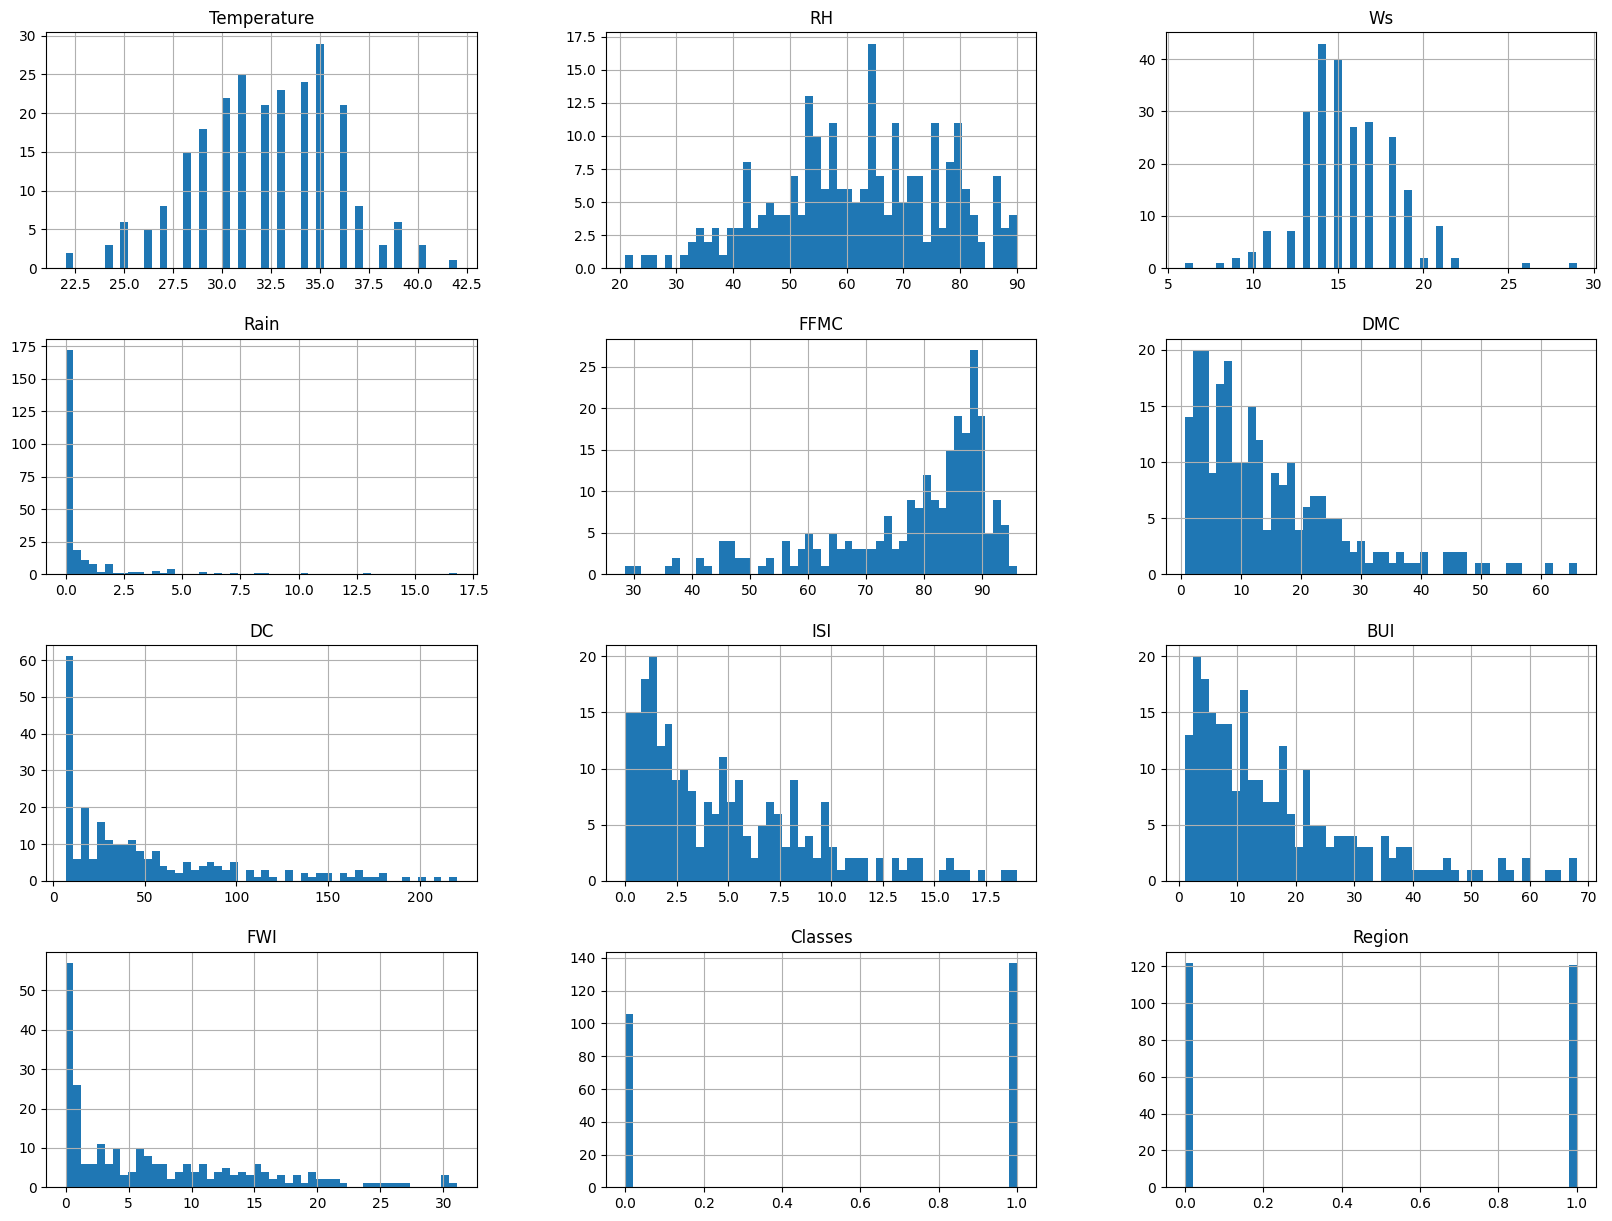

In [34]:
# plot density plot for all feature
df_copy.hist(bins=50,figsize=(20,15))

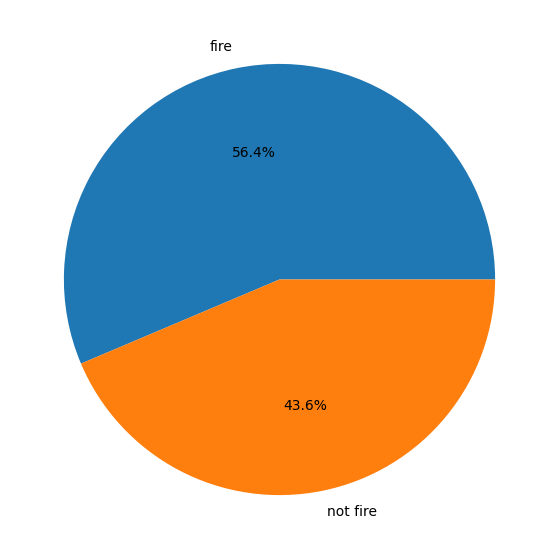

In [35]:
per=df_copy['Classes'].value_counts(normalize=True)*100
classlabel=['fire','not fire']
plt.figure(figsize=(12,7))
plt.pie(per,labels=classlabel,autopct="%1.1f%%")
plt.show()

In [36]:
# corelation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

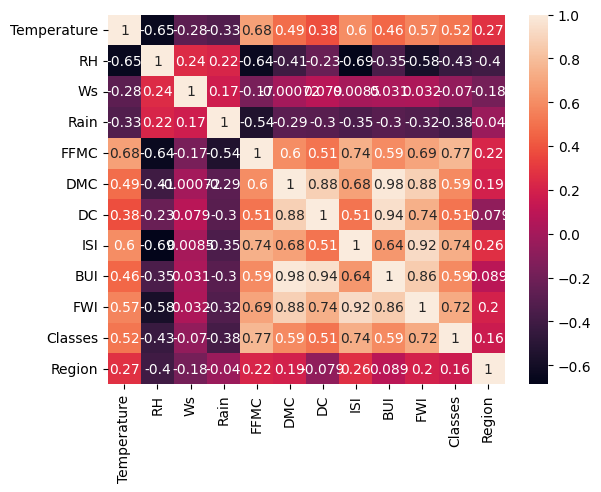

In [37]:
sns.heatmap(df_copy.corr(),annot=True)

<Axes: ylabel='Temperature'>

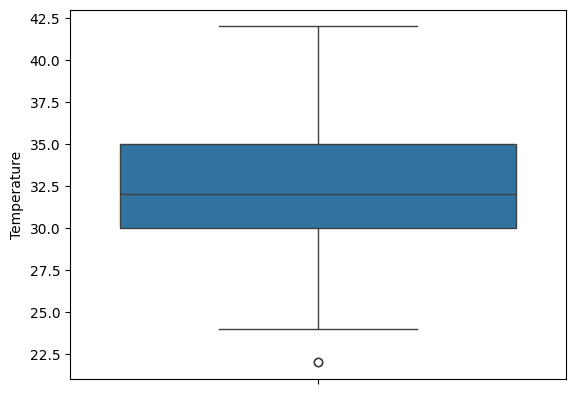

In [38]:
# boxplot of dependent feature to check if there is any outliers
sns.boxplot(df_copy['Temperature'])

In [39]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

Text(0.5, 1.0, 'fire analysis of sidi-bel regions')

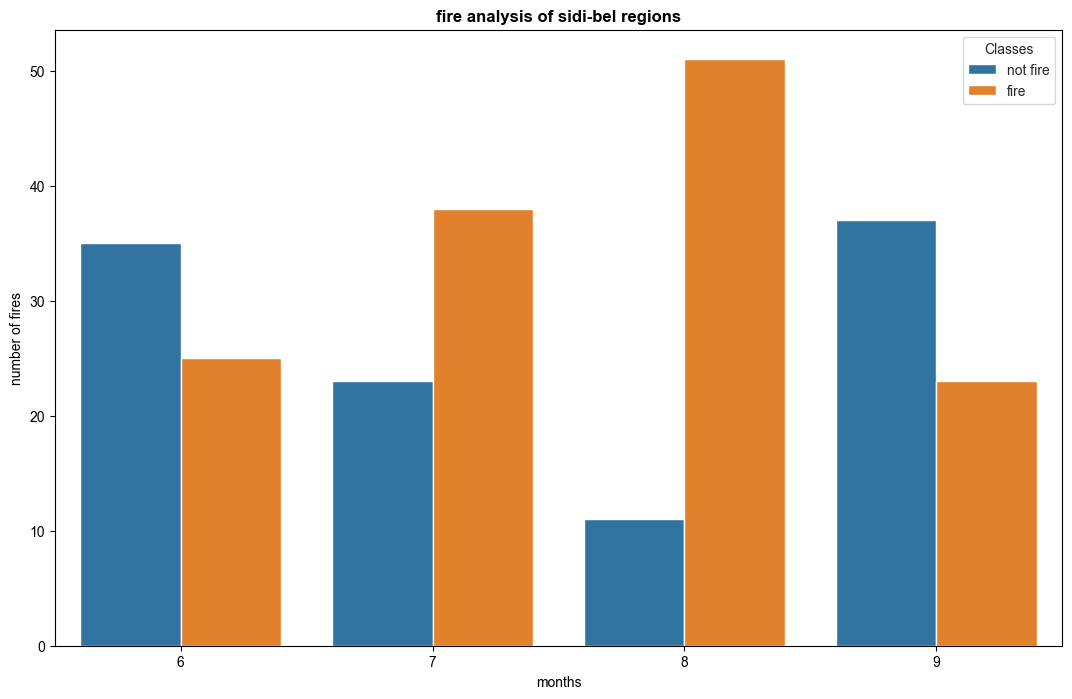

In [40]:
# monthly analysis
dtemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,8))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.xlabel('months')
plt.ylabel('number of fires')
plt.title("fire analysis of sidi-bel regions",weight='bold')

Text(0.5, 1.0, 'fire analysis of brjaia regions')

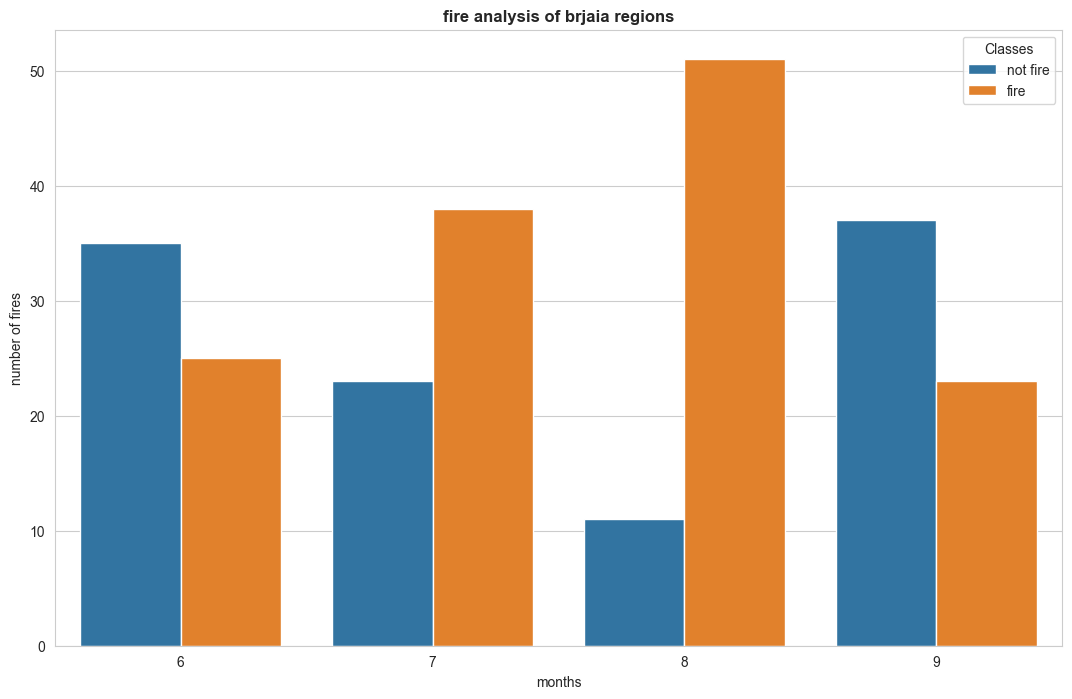

In [41]:
dtemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,8))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.xlabel('months')
plt.ylabel('number of fires')
plt.title("fire analysis of brjaia regions",weight='bold')

In [42]:
# independent and dependent features
X=df_copy.drop('Temperature',axis=1)
Y=df_copy['Temperature']

In [43]:
# model training
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [44]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((182, 11), (61, 11), (182,), (61,))

<Axes: >

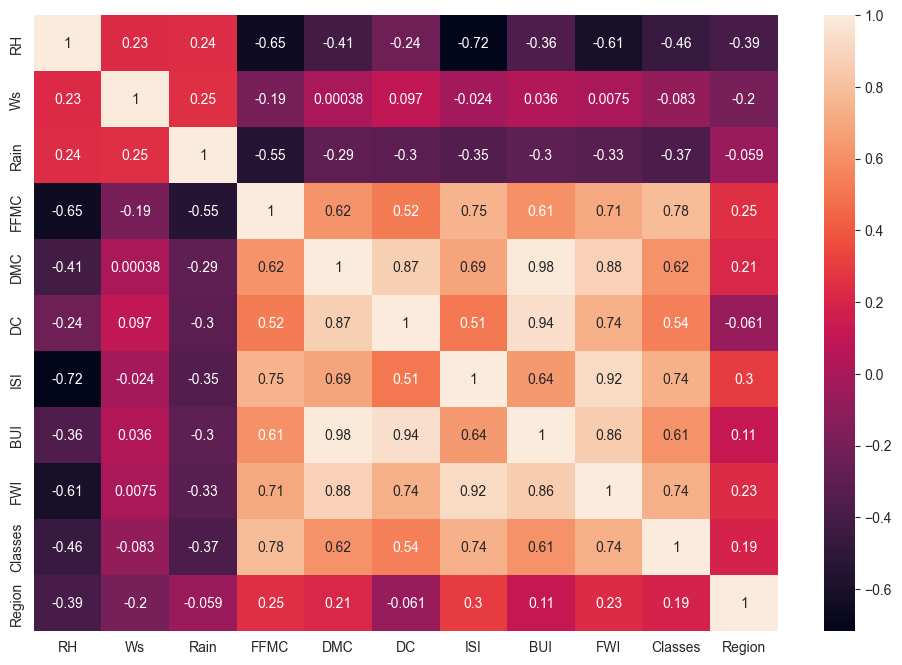

In [45]:
# feature selection
plt.figure(figsize=(12,8))
corr=X_train.corr()
sns.heatmap(corr,annot=True)


In [46]:
def correlation(dataset,threshold):
  col_corr=set()
  corr_matrix=dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j])>threshold:
        colname=corr_matrix.columns[i]
        col_corr.add(colname)
  return col_corr

In [47]:
corr_feature=correlation(X_train,0.85)

In [48]:
X_train.drop(corr_feature,axis=1,inplace=True)
X_test.drop(corr_feature,axis=1,inplace=True)

In [49]:
X_train.shape,X_test.shape

((182, 8), (61, 8))

In [50]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train_scale=scale.fit_transform(X_train)
X_test_scale=scale.transform(X_test)

In [51]:
X_test_scale.shape

(61, 8)

Text(0.5, 1.0, 'X_train after scalling')

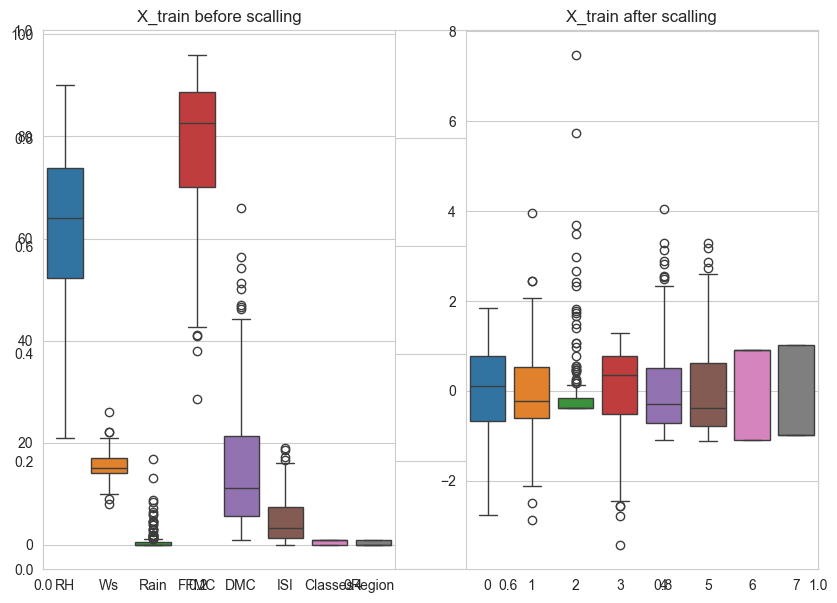

In [52]:
# boxplot before standardization
plt.subplots(figsize=(10,7))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train before scalling")
plt.subplot(1,2,2)
sns.boxplot(X_train_scale)
plt.title("X_train after scalling")

In [53]:
from sklearn.linear_model import LinearRegression
regre=LinearRegression()
regre.fit(X_train_scale,Y_train)
y_pred=regre.predict(X_test_scale)

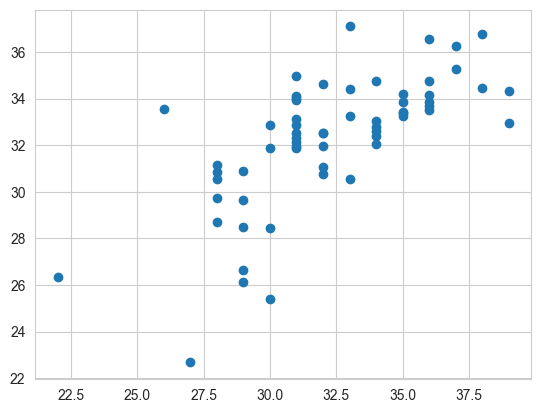

In [54]:
plt.scatter(Y_test,y_pred)

In [55]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
mae=mean_absolute_error(y_pred,Y_test)
mse=mean_squared_error(y_pred,Y_test)
rmse=root_mean_squared_error(y_pred,Y_test)
score=r2_score(y_pred,Y_test)
print(mae,mse,rmse,score)

2.07277162967601 6.339735428378812 2.5178831244477595 0.184793411279222


In [56]:
# lasso regreeesion
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_scale,Y_train)
y_predict=lasso.predict(X_test_scale)
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
mae=mean_absolute_error(y_predict,Y_test)
mse=mean_squared_error(y_predict,Y_test)
rmse=root_mean_squared_error(y_predict,Y_test)
score=r2_score(y_predict,Y_test)
print(mae,mse,rmse,score)



2.133660267664301 6.526166015862152 2.5546361807236178 -1.5199575368904497


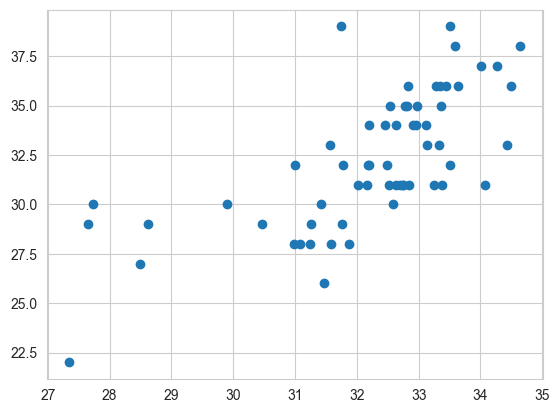

In [57]:
plt.scatter(y_predict,Y_test)

In [58]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scale,Y_train)


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [59]:
lassocv.alpha_

np.float64(0.06820995274781677)

In [60]:
lassocv.alphas_

array([2.56806093, 2.39498222, 2.23356844, 2.0830334 , 1.94264392,
       1.81171622, 1.68961261, 1.57573838, 1.46953888, 1.37049688,
       1.27812998, 1.1919883 , 1.11165227, 1.03673063, 0.96685846,
       0.90169543, 0.84092418, 0.7842487 , 0.73139297, 0.68209953,
       0.6361283 , 0.59325538, 0.55327196, 0.51598328, 0.48120773,
       0.44877594, 0.41852995, 0.39032243, 0.364016  , 0.33948254,
       0.31660256, 0.2952646 , 0.27536476, 0.25680609, 0.23949822,
       0.22335684, 0.20830334, 0.19426439, 0.18117162, 0.16896126,
       0.15757384, 0.14695389, 0.13704969, 0.127813  , 0.11919883,
       0.11116523, 0.10367306, 0.09668585, 0.09016954, 0.08409242,
       0.07842487, 0.0731393 , 0.06820995, 0.06361283, 0.05932554,
       0.0553272 , 0.05159833, 0.04812077, 0.04487759, 0.04185299,
       0.03903224, 0.0364016 , 0.03394825, 0.03166026, 0.02952646,
       0.02753648, 0.02568061, 0.02394982, 0.02233568, 0.02083033,
       0.01942644, 0.01811716, 0.01689613, 0.01575738, 0.01469

In [61]:
lassocv.mse_path_

array([[13.84084198, 11.48490936, 14.72469819, 10.7755376 , 16.83532975],
       [13.0007788 , 11.03360493, 14.43973249, 10.09099203, 16.51847506],
       [12.24706211, 10.64489771, 13.43318144,  9.50990971, 15.84276594],
       [11.59017433, 10.31037728, 12.47663598,  8.93882635, 15.21830117],
       [10.96825734, 10.022746  , 11.61696037,  8.40538826, 14.35731329],
       [10.30705765,  9.77567294, 10.87011991,  7.95664704, 13.59500004],
       [ 9.7318879 ,  9.39824941, 10.22132216,  7.58055629, 12.91938303],
       [ 9.23152071,  9.07000918,  9.65779555,  7.26666707, 12.32003358],
       [ 8.79622064,  8.79156323,  9.16835785,  7.00604416, 11.78780848],
       [ 8.41751979,  8.54989829,  8.74331245,  6.79088684, 11.31470214],
       [ 8.08805272,  8.34023375,  8.38041286,  6.6144968 , 10.8937391 ],
       [ 7.80136118,  8.1583662 ,  8.06942978,  6.47110055, 10.51869848],
       [ 7.55198236,  8.00072626,  7.8031833 ,  6.35572538, 10.18423014],
       [ 7.33501053,  7.86396431,  7.5

2.010347115130689 0.15150684834982242


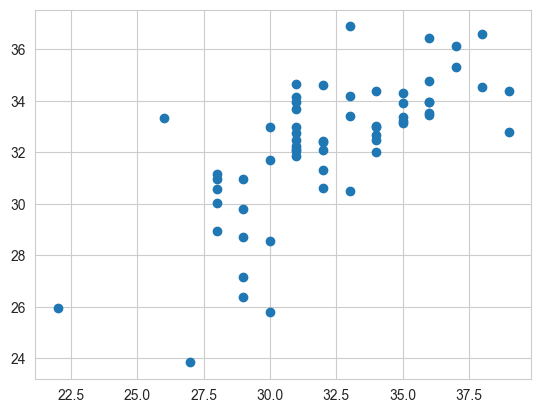

In [62]:
y_lassocv=lassocv.predict(X_test_scale)
plt.scatter(Y_test,y_lassocv)
mae=mean_absolute_error(y_lassocv,Y_test)
score=r2_score(y_lassocv,Y_test)
print(mae,score)

In [63]:
# ridge regreeesion
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train_scale,Y_train)
y_pre=ridge.predict(X_test_scale)
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
mae=mean_absolute_error(y_pre,Y_test)
mse=mean_squared_error(y_pre,Y_test)
rmse=root_mean_squared_error(y_pre,Y_test)
score=r2_score(y_pre,Y_test)
print(mae,mse,rmse,score)

2.0691508461335566 6.316242975607127 2.5132136748806553 0.18083091069042845


2.0436226282770655 0.14554822885749208


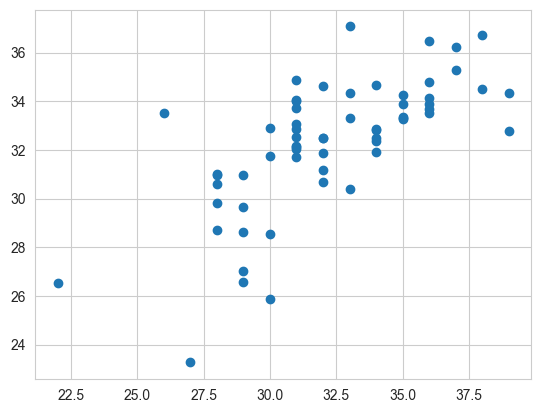

In [64]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scale,Y_train)
y_ridgecv=ridgecv.predict(X_test_scale)
plt.scatter(Y_test,y_ridgecv)
mae=mean_absolute_error(y_ridgecv,Y_test)
score=r2_score(y_ridgecv,Y_test)
print(mae,score)

In [65]:
ridgecv.alpha_

np.float64(10.0)

In [66]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [67]:
ridgecv.gcv_mode

In [68]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

In [69]:
# elastivnet regreeesion
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_scale,Y_train)
y_predict=lasso.predict(X_test_scale)
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
mae=mean_absolute_error(y_predict,Y_test)
mse=mean_squared_error(y_predict,Y_test)
rmse=root_mean_squared_error(y_predict,Y_test)
score=r2_score(y_predict,Y_test)
print(mae,mse,rmse,score)

2.133660267664301 6.526166015862152 2.5546361807236178 -1.5199575368904497


1.984195628948377 0.03331755511138379


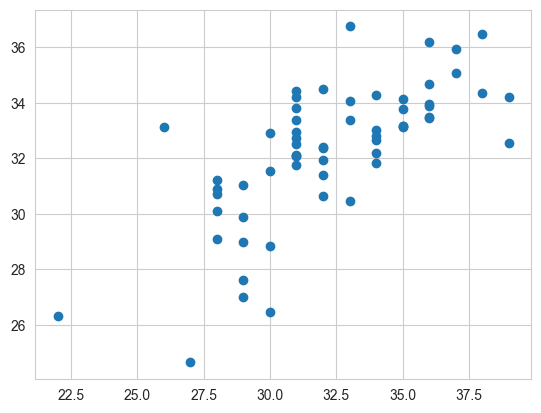

In [70]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv=ElasticNetCV(cv=4)
elasticnetcv.fit(X_train_scale,Y_train)
y_elastic=elasticnetcv.predict(X_test_scale)
plt.scatter(Y_test,y_elastic)
mae=mean_absolute_error(y_elastic,Y_test)
score=r2_score(y_elastic,Y_test)
print(mae,score)

In [71]:
elasticnetcv.alphas

'warn'

In [72]:
elasticnetcv.alpha_

np.float64(0.20734612629820517)

In [73]:
elasticnetcv.alphas_

array([5.13612187, 4.78996445, 4.46713687, 4.1660668 , 3.88528784,
       3.62343244, 3.37922522, 3.15147675, 2.93907777, 2.74099376,
       2.55625996, 2.38397659, 2.22330455, 2.07346126, 1.93371691,
       1.80339087, 1.68184836, 1.56849741, 1.46278593, 1.36419905,
       1.2722566 , 1.18651077, 1.10654391, 1.03196656, 0.96241546,
       0.89755188, 0.83705989, 0.78064486, 0.728032  , 0.67896508,
       0.63320511, 0.5905292 , 0.55072951, 0.51361219, 0.47899644,
       0.44671369, 0.41660668, 0.38852878, 0.36234324, 0.33792252,
       0.31514768, 0.29390778, 0.27409938, 0.255626  , 0.23839766,
       0.22233045, 0.20734613, 0.19337169, 0.18033909, 0.16818484,
       0.15684974, 0.14627859, 0.13641991, 0.12722566, 0.11865108,
       0.11065439, 0.10319666, 0.09624155, 0.08975519, 0.08370599,
       0.07806449, 0.0728032 , 0.06789651, 0.06332051, 0.05905292,
       0.05507295, 0.05136122, 0.04789964, 0.04467137, 0.04166067,
       0.03885288, 0.03623432, 0.03379225, 0.03151477, 0.02939

In [74]:
import pickle
pickle.dump(scale,open('scale.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))